# Nuclear Waste Canister Temperature Prediction
**CIVIL-226 - Introduction to Machine Learning for Engineers**   
**Members:** NAJA Nour | CLERICI Alessandro


**SCIPERS:** 381 792 |

## Objectif
Prédire la température autour de conteneurs de déchets nucléaires à des positions de capteurs non observés, en utilisant la puissance de chauffage, le temps, et les coordonnées spatiales 3D des capteurs.

## 1. Imports

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"


In [2]:
import torch
import torchvision

In [3]:
torch.__version__

'2.11.0+cpu'

In [4]:
torchvision.__version__

'0.26.0+cpu'

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
np.random.seed(42)
print('Imports OK')

Imports OK


## 2. Chargement des données

In [6]:
sensors = pd.read_parquet('data/sensors.parquet')
train   = pd.read_parquet('data/train.parquet')
test    = pd.read_parquet('data/test.parquet')

n_before = len(sensors)
sensors = sensors.drop_duplicates(subset='sensor', keep='first').reset_index(drop=True)
print(f'Doublons supprimés : {n_before - len(sensors)} (N206, N213)')

print(f'Sensors : {sensors.shape}  ->  {sensors.columns.tolist()}')
print(f'Train   : {train.shape}   ->  {train.columns.tolist()}')
print(f'Test    : {test.shape}    ->  {test.columns.tolist()}')

Doublons supprimés : 2 (N206, N213)
Sensors : (323, 4)  ->  ['sensor', 'coor_x', 'coor_y', 'coor_z']
Train   : (6626928, 4)   ->  ['sensor', 'time', 'power', 'temperature']
Test    : (2190480, 3)    ->  ['sensor', 'time', 'power']


## 3. Exploration des données (EDA)

In [7]:
print('=== SENSORS ===')
display(sensors.head())
print(f'\n{sensors["sensor"].nunique()} capteurs uniques')

print('\n=== TRAIN ===')
display(train.head())
print(f'\nValeurs manquantes :')
print(train.isnull().sum())

=== SENSORS ===


,sensor,coor_x,coor_y,coor_z
0,N2,0.5,0.0,0.0
1,N4,1.4,0.0,0.0
2,N5,0.5,2.4,0.0
3,N6,0.0,2.4,0.0
4,N7,0.0,3.5,0.0



323 capteurs uniques

=== TRAIN ===


,sensor,time,power,temperature
0,N102,0.0,1487.964722,17.514429
1,N102,864000.0,1487.288818,17.820795
2,N102,1728000.0,1486.612915,17.573187
3,N102,2592000.0,1485.936890,16.513235
4,N102,3456000.0,1485.260986,16.303427



Valeurs manquantes :
sensor             0
time               0
power              0
temperature    99403
dtype: int64


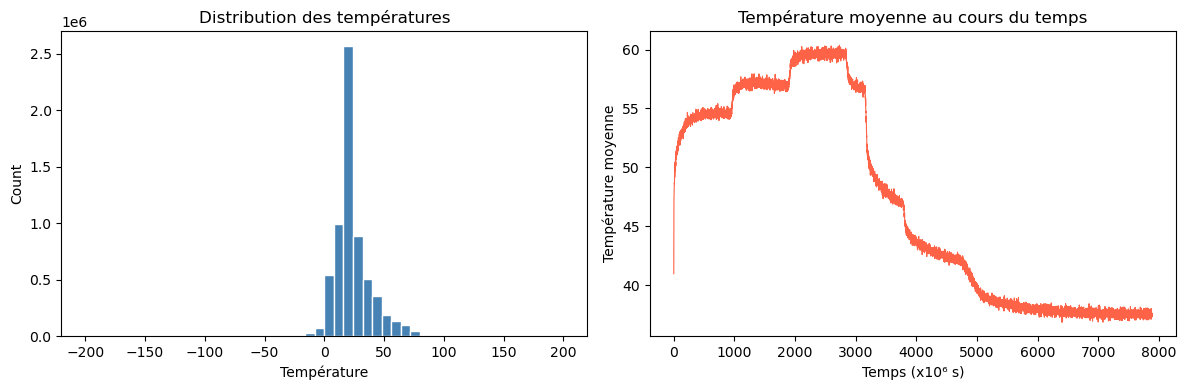

In [8]:
# Distribution de la température cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['temperature'].dropna(), bins=50, color='steelblue', edgecolor='white',
             range=(-200, 200))
axes[0].set_title('Distribution des températures')
axes[0].set_xlabel('Température')
axes[0].set_ylabel('Count')

# Évolution temporelle (moyenne sur tous les capteurs)
temp_by_time = train.groupby('time')['temperature'].mean()
axes[1].plot(temp_by_time.index / 1e6, temp_by_time.values, color='tomato', linewidth=0.8)
axes[1].set_title('Température moyenne au cours du temps')
axes[1].set_xlabel('Temps (x10⁶ s)')
axes[1].set_ylabel('Température moyenne')

plt.tight_layout()
plt.show()

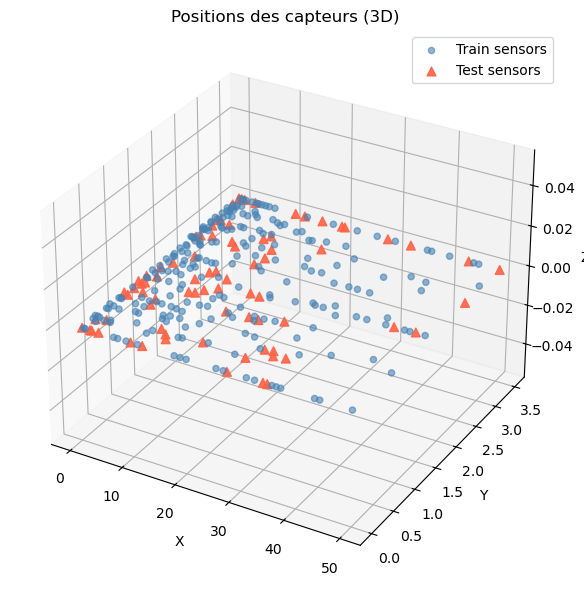

In [9]:
# Positions des capteurs dans l'espace
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Séparer capteurs train vs test
train_sensors = set(train['sensor'].unique())
test_sensors  = set(test['sensor'].unique())

s_train = sensors[sensors['sensor'].isin(train_sensors)]
s_test  = sensors[sensors['sensor'].isin(test_sensors)]

ax.scatter(s_train['coor_x'], s_train['coor_y'], s_train['coor_z'],
           c='steelblue', label='Train sensors', alpha=0.6, s=20)
ax.scatter(s_test['coor_x'], s_test['coor_y'], s_test['coor_z'],
           c='tomato', label='Test sensors', alpha=0.9, s=40, marker='^')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Positions des capteurs (3D)')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
import plotly.graph_objects as go

# Séparer capteurs train vs test
train_sensors = set(train['sensor'].unique())
test_sensors  = set(test['sensor'].unique())

s_train = sensors[sensors['sensor'].isin(train_sensors)]
s_test  = sensors[sensors['sensor'].isin(test_sensors)]

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=s_train['coor_x'],
    y=s_train['coor_y'],
    z=s_train['coor_z'],
    mode='markers',
    name='Train sensors',
    marker=dict(size=4, color='steelblue', opacity=0.6)
))

fig.add_trace(go.Scatter3d(
    x=s_test['coor_x'],
    y=s_test['coor_y'],
    z=s_test['coor_z'],
    mode='markers',
    name='Test sensors',
    marker=dict(size=6, color='tomato', symbol='diamond', opacity=0.9)
))

fig.update_layout(
    title='Positions des capteurs (3D interactif)',
    width=700, height=600,
    margin=dict(l=0, r=0, b=0, t=40),
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    legend=dict(yanchor='top', y=0.99, xanchor='left', x=0.01)
)

fig.show()

## 4. Preprocessing

### 4.1 Gestion des valeurs manquantes
Le train set contient ~99k valeurs de température manquantes. On les supprime car on ne peut pas les utiliser pour entraîner le modèle.

In [12]:
print(f'Lignes avant nettoyage : {len(train)}')
train_clean = train.dropna(subset=['temperature']).copy()
print(f'Lignes après suppression NaN : {len(train_clean)}')
print(f'Supprimées : {len(train) - len(train_clean)} ({100*(len(train)-len(train_clean))/len(train):.1f}%)')

Lignes avant nettoyage : 6626928
Lignes après suppression NaN : 6527525
Supprimées : 99403 (1.5%)


In [13]:
# Nettoyage sensors : suppression des doublons (N206 et N213 apparaissent deux fois 
# avec des coordonnées identiques — erreur de reporting dans les données sources)
print(f'Sensors avant dédoublonnage : {len(sensors)}')
sensors = sensors.drop_duplicates(subset='sensor', keep='first')
print(f'Sensors après dédoublonnage : {len(sensors)}')

Sensors avant dédoublonnage : 323
Sensors après dédoublonnage : 323


### 4.2 Feature Engineering

On joint les positions 3D des capteurs au dataframe, et on ajoute des features dérivées utiles.

In [14]:
def add_features(df, sensors_df):
    """
    Joint les coordonnées et ajoute des features dérivées.
    
    Features ajoutées :
    - coor_x, coor_y : position spatiale
    - dist_center : distance à l'origine (r = sqrt(x²+y²))
    - dist_canister : distance au centre du canister (x=0.7, y=1.2)
    - is_opa : 1 si dans la zone OPA (x > 1.4), 0 si buffer
    - time_norm : temps normalisé entre 0 et 1
    - time_log : log du temps (capture la décroissance exponentielle)
    """
    merged = df.merge(sensors_df, on='sensor', how='left')
    
    # Features spatiales
    merged['dist_center']   = np.sqrt(merged['coor_x']**2 + merged['coor_y']**2)
    merged['dist_canister'] = np.sqrt((merged['coor_x'] - 0.7)**2 + (merged['coor_y'] - 1.2)**2)
    merged['is_opa']        = (merged['coor_x'] > 1.4).astype(float)
    
    # Features temporelles
    t_max = train_clean['time'].max()
    merged['time_norm'] = merged['time'] / t_max
    merged['time_log']  = np.log1p(merged['time'])
    
    return merged

In [17]:
train_feat = add_features(train_clean, sensors)
test_feat  = add_features(test, sensors)

print('Features disponibles :', train_feat.columns.tolist())
display(train_feat.head(3))

Features disponibles : ['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z', 'dist_center', 'dist_canister', 'is_opa', 'time_norm', 'time_log']


,sensor,time,power,temperature,coor_x,coor_y,coor_z,dist_center,dist_canister,is_opa,time_norm,time_log
0,N102,0.0,1487.964722,17.514429,46.131474,3.5,0.0,46.264053,45.489655,1.0,0.000000,0.000000
1,N102,864000.0,1487.288818,17.820795,46.131474,3.5,0.0,46.264053,45.489655,1.0,0.000110,13.669329
2,N102,1728000.0,1486.612915,17.573187,46.131474,3.5,0.0,46.264053,45.489655,1.0,0.000219,14.362476


In [18]:
TARGET = 'temperature'

FEATURES = ['coor_x', 'coor_y', 'time_norm', 'time_log', 'power', 
            'dist_center', 'dist_canister', 'is_opa']

X = train_feat[FEATURES].values
y = train_feat[TARGET].values
X_test = test_feat[FEATURES].values

print(f'X shape : {X.shape}')
print(f'X_test shape : {X_test.shape}')

X shape : (6527525, 8)
X_test shape : (2190480, 8)


### 4.3 Split train/validation & Normalisation

In [21]:
# Split 80/20
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisation
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

# test_feat déjà construit par add_features() avec toutes les features
X_test_s = scaler.transform(test_feat[FEATURES].values)

assert len(X_test_s) == len(test)
print(f'Train : {X_train_s.shape} | Val : {X_val_s.shape} | Test : {X_test_s.shape}')

Train : (5222020, 8) | Val : (1305505, 8) | Test : (2190480, 8)


## 5. Modèle Baseline — Ridge Regression

On commence par un modèle simple comme baseline. La régression Ridge est rapide, interprétable, et constitue un bon point de référence.

In [22]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)

y_pred_val_ridge = ridge.predict(X_val_s)
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_val_ridge))

print(f'Baseline Ridge — RMSE validation : {rmse_ridge:.4f}')

Baseline Ridge — RMSE validation : 387.4102


## 6. Modèle amélioré — k-Nearest Neighbors

kNN est naturellement adapté à ce problème : la température en un point dépend de ses voisins spatiaux et temporels. On cherche le meilleur k par validation.

In [23]:
# Recherche du meilleur k (sur un sous-ensemble pour la rapidité)
# On utilise un sample pour éviter des temps de calcul trop longs
sample_size = min(50000, len(X_train_s))
idx = np.random.choice(len(X_train_s), sample_size, replace=False)

k_values = [3, 5, 10, 20]
rmse_k = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_s[idx], y_train[idx])
    pred = knn.predict(X_val_s[:5000])  # validation partielle
    rmse = np.sqrt(mean_squared_error(y_val[:5000], pred))
    rmse_k.append(rmse)
    print(f'k={k:3d}  ->  RMSE = {rmse:.4f}')

best_k = k_values[np.argmin(rmse_k)]
print(f'\nMeilleur k : {best_k}')

k=  3  ->  RMSE = 214.1035
k=  5  ->  RMSE = 242.4788
k= 10  ->  RMSE = 288.6163
k= 20  ->  RMSE = 300.7710

Meilleur k : 3


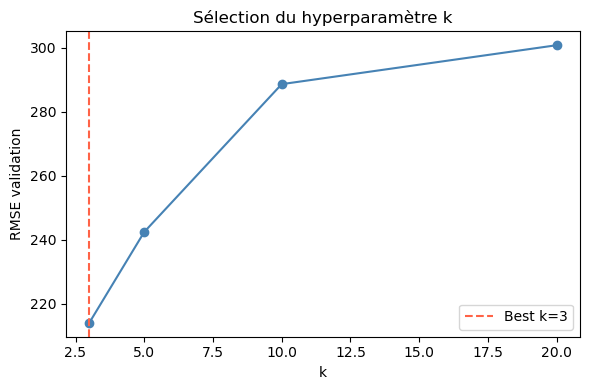

In [24]:
# Visualisation de la recherche de k
plt.figure(figsize=(6, 4))
plt.plot(k_values, rmse_k, 'o-', color='steelblue')
plt.axvline(best_k, color='tomato', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k'); plt.ylabel('RMSE validation')
plt.title('Sélection du hyperparamètre k')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Entraînement final du kNN avec le meilleur k sur toutes les données
knn_final = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn_final.fit(X_train_s, y_train)

y_pred_val_knn = knn_final.predict(X_val_s)
rmse_knn = np.sqrt(mean_squared_error(y_val, y_pred_val_knn))
print(f'kNN (k={best_k}) — RMSE validation : {rmse_knn:.4f}')

kNN (k=3) — RMSE validation : 23.7373


## 8. SVM trees: Modèle — Random Forest

#  8.1 Filtrage des valeurs aberrantes 

In [26]:
from sklearn.ensemble import RandomForestRegressor

# 8.1 Filtrage des outliers AVANT le split
# On filtre sur y (température) avant de séparer train/val
# pour éviter que les outliers contaminent l'évaluation
mask_all = (y > -10) & (y < 200)
print(f'Aberrants supprimés : {(~mask_all).sum()} sur {len(y)}')
X_clean = X[mask_all]
y_clean = y[mask_all]

# Nouveau split sur données propres
X_train, X_val, y_train, y_val = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

# Reconstruire X_test_s proprement
test_feat_aligned = test.merge(sensors, on='sensor', how='left')
test_feat_aligned['dist_center'] = np.sqrt(test_feat_aligned['coor_x']**2 + test_feat_aligned['coor_y']**2)
test_feat_aligned['time_norm'] = test_feat_aligned['time'] / train_clean['time'].max()
X_test_s = scaler.transform(test_feat_aligned[FEATURES].values)

Aberrants supprimés : 108713 sur 6527525


KeyError: "['time_log', 'dist_canister', 'is_opa'] not in index"

8.2 Sample pour accélerer

In [21]:

np.random.seed(42)
idx = np.random.choice(len(X_train_s), size=200_000, replace=False)


8.3 training

In [22]:


rf = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf.fit(X_train_s[idx], y_train[idx])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

8.4 Evaluation

In [24]:
y_pred_val_rf = rf.predict(X_val_s)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_val_rf))
print(f'Random Forest RMSE : {rmse_rf:.4f}')
print(f'kNN RMSE : {rmse_knn:.4f}')
print(f'Ridge RMSE : {rmse_ridge:.4f}')

Random Forest RMSE : 4.2986
kNN RMSE : 12.5741
Ridge RMSE : 387.8511


8.5 Feature importance

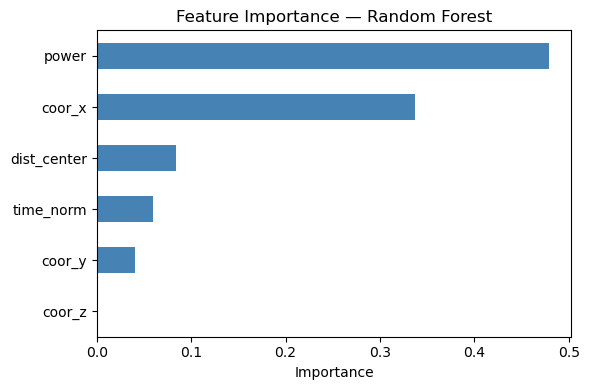

In [25]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(6,4), color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## Gradient Boosting Extension naturelle des Decision Trees (lab svm_trees, section 3)
### Au lieu d'entraîner des arbres indépendants (Random Forest), le Gradient Boosting entraîne chaque arbre pour corriger les erreurs du précédent via descente de gradient sur la loss — d'où le lien direct avec SGD vu en cours

In [35]:
from sklearn.ensemble import GradientBoostingRegressor

# Sample plus petit car GBR est plus lent (arbres séquentiels)
np.random.seed(42)
idx_gb = np.random.choice(len(X_train_s), size=500_000, replace=False)
X_gb = X_train_s[idx_gb]
y_gb = y_train[idx_gb]

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=20,
    random_state=42
)
gb.fit(X_gb, y_gb)

y_pred_val_gb = gb.predict(X_val_s)
rmse_gb = np.sqrt(mean_squared_error(y_val, y_pred_val_gb))
print(f'Gradient Boosting — RMSE : {rmse_gb:.4f}')
print(f'Random Forest     — RMSE : {rmse_rf:.4f}')
print(f'kNN               — RMSE : {rmse_knn:.4f}')
print(f'Ridge             — RMSE : {rmse_ridge:.4f}')

Gradient Boosting — RMSE : 5.0807
Random Forest     — RMSE : 4.2986
kNN               — RMSE : 12.5741
Ridge             — RMSE : 387.8511


## 9. Comparaison des modèles

,Modèle,RMSE Validation
0,Gradient Boosting,3.987679
1,Random Forest,4.298602
2,kNN (k=3),12.574096
3,Ridge (baseline),387.851074


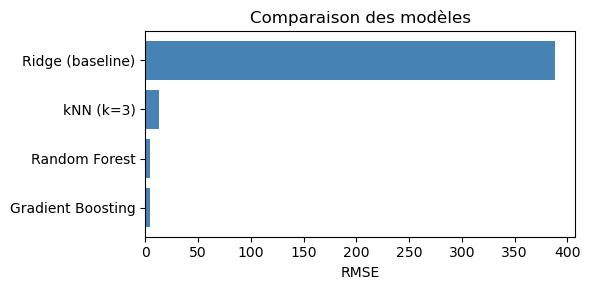

In [32]:
results = pd.DataFrame({
    'Modèle': ['Ridge (baseline)', f'kNN (k={best_k})', 'Random Forest', 'Gradient Boosting'],
    'RMSE Validation': [rmse_ridge, rmse_knn, rmse_rf, rmse_gb]
})
results = results.sort_values('RMSE Validation').reset_index(drop=True)
display(results)

plt.figure(figsize=(6, 3))
plt.barh(results['Modèle'], results['RMSE Validation'], color='steelblue')
plt.xlabel('RMSE')
plt.title('Comparaison des modèles')
plt.tight_layout()
plt.show()

## 10. Prédictions finales & Soumission

On utilise le meilleur modèle parmi les 3.

In [34]:
# Choisir le meilleur modèle
best_rmse = min(rmse_ridge, rmse_knn, rmse_rf, rmse_gb)

if best_rmse == rmse_gb:
    y_pred = gb.predict(X_test_s)
    best_model_name = 'Gradient Boosting'
elif best_rmse == rmse_rf:
    y_pred = rf.predict(X_test_s)
    best_model_name = 'Random Forest'
elif best_rmse == rmse_knn:
    y_pred = knn_final.predict(X_test_s)
    best_model_name = f'kNN (k={best_k})'
else:
    y_pred = ridge.predict(X_test_s)
    best_model_name = 'Ridge'

print(f'Modèle sélectionné : {best_model_name} (RMSE = {best_rmse:.4f})')

submission = pd.DataFrame({
    'Id': np.arange(len(test), dtype=int),
    'temperature': y_pred.astype(float)
})

assert list(submission.columns) == ['Id', 'temperature']
assert len(submission) == len(test)
assert np.isfinite(submission['temperature']).all()
assert submission.isna().sum().sum() == 0

submission.to_csv('submission.csv', index=False)
print(f'submission.csv sauvegardé — {len(submission)} lignes')
display(submission.head())

Modèle sélectionné : Gradient Boosting (RMSE = 3.9877)
submission.csv sauvegardé — 2190480 lignes


,Id,temperature
0,0,16.064137
1,1,16.064137
2,2,16.064137
3,3,16.200923
4,4,16.200923


## 11. Pistes d'amélioration

- **Gradient Boosting** (XGBoost, LightGBM) : souvent plus performant que kNN sur ce type de données
- **Réseau de neurones** (PyTorch) : peut capturer des relations non-linéaires complexes
- **Features supplémentaires** : distance au canister en 3D, angle, features temporelles (sin/cos du temps pour capter la périodicité)
- **Interpolation spatiale** : pondérer les voisins par leur distance dans l'espace 3D